# Collins 2026Feb beamtime local curation workflow

Use the already-ingested local catalog/zarr view (no NAS dependency), inspect relevant scans, apply per-scan sample/tag updates, verify theta/energy ranges, and correct per-scan classification (`fixed_energy` vs `fixed_angle`).

This notebook is structured as executable validation steps so each curation action is immediately checked.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from pyref.io import (
    apply_scan_overrides,
    get_image,
    read_beamtime_local,
    set_beamtime_scan_types,
    summarize_beamtime_scans,
)

In [2]:
BEAMTIME = Path("/Volumes/DATA/Collins/2026Feb")

assert BEAMTIME.is_absolute(), f"beamtime must be absolute: {BEAMTIME}"
print(f"beamtime exists on filesystem: {BEAMTIME.exists()}")
BEAMTIME

beamtime exists on filesystem: True


PosixPath('/Volumes/DATA/Collins/2026Feb')

In [3]:
view = read_beamtime_local(BEAMTIME, require_indexed=True)

print(f"catalog: {view.catalog_path}")
print(f"beamtime: {view.beamtime_path}")
print(f"frames: {view.frames.height}")
print(f"samples: {len(view.entries.samples)}")
print(f"scans: {len(view.entries.scans)}")

view.frames.head(5)

catalog: /Users/hduva/.config/pyref/catalog.db
beamtime: /Volumes/DATA/Collins/2026Feb
frames: 13546
samples: 9
scans: 33


file_path,data_offset,naxis1,naxis2,bitpix,bzero,data_size,file_name,sample_name,tag,scan_number,frame_number,zarr_group_key,zarr_frame_index,zarr_bucket_frame_index,zarr_path,DATE,Beamline Energy,Sample Theta,CCD Theta,Higher Order Suppressor,EPU Polarization,EXPOSURE,AI 3 Izero,Sample Name,Scan ID,Lambda,Q,beam_row,beam_col,beam_sigma,reflectivity_profile_index,reflectivity_scan_type,catalog_scan_type
str,i64,i64,i64,i64,i64,i64,str,str,str,i64,i64,i64,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,i64,i64,f64,i64,str,str
"""/Volumes/DATA/Collins/2026Feb/…",20160,1000,400,16,32768,800000,"""opv_ternary_88147-00001.fits""","""opv""","""ternary""",88147,1,88147,1,0,"""/Users/hduva/Library/Applicati…","""2026-02-10T14:37:17""",249.998516,0.0,0.001,null,190.0,0.0,0.0,"""opv""",88147.0,null,null,null,null,null,null,null,"""fixed_energy"""
"""/Volumes/DATA/Collins/2026Feb/…",20160,1000,400,16,32768,800000,"""opv_ternary_88147-00002.fits""","""opv""","""ternary""",88147,2,88147,2,1,"""/Users/hduva/Library/Applicati…","""2026-02-10T14:37:20""",250.000403,0.0,0.0,null,190.0,0.0,0.0,"""opv""",88147.0,null,null,null,null,null,null,null,"""fixed_energy"""
"""/Volumes/DATA/Collins/2026Feb/…",20160,1000,400,16,32768,800000,"""opv_ternary_88147-00003.fits""","""opv""","""ternary""",88147,3,88147,3,2,"""/Users/hduva/Library/Applicati…","""2026-02-10T14:37:23""",250.000403,0.0,0.0,null,190.0,0.0,0.0,"""opv""",88147.0,null,null,null,null,null,null,null,"""fixed_energy"""
"""/Volumes/DATA/Collins/2026Feb/…",20160,1000,400,16,32768,800000,"""opv_ternary_88147-00004.fits""","""opv""","""ternary""",88147,4,88147,4,3,"""/Users/hduva/Library/Applicati…","""2026-02-10T14:37:26""",250.000403,0.0,0.0,null,190.0,0.0,0.0,"""opv""",88147.0,null,null,null,null,null,null,null,"""fixed_energy"""
"""/Volumes/DATA/Collins/2026Feb/…",20160,1000,400,16,32768,800000,"""opv_ternary_88147-00005.fits""","""opv""","""ternary""",88147,5,88147,5,4,"""/Users/hduva/Library/Applicati…","""2026-02-10T14:37:29""",250.000403,0.0,0.0,null,190.0,0.0,0.0,"""opv""",88147.0,null,null,null,null,null,null,null,"""fixed_energy"""


In [4]:
import polars as pl
summary_all = summarize_beamtime_scans(BEAMTIME)

assert summary_all.height > 0, "no scans found for beamtime"
# Configure polars to print all rows
pl.Config.set_tbl_rows(-1)
pl.Config.set_tbl_cols(-1)
print(summary_all)

shape: (33, 10)
┌─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬────────┐
│ scan_nu ┆ n_frame ┆ sample_ ┆ tags    ┆ energy_ ┆ energy_ ┆ theta_m ┆ theta_m ┆ inferre ┆ catalo │
│ mber    ┆ s       ┆ names   ┆ ---     ┆ min     ┆ max     ┆ in      ┆ ax      ┆ d_scan_ ┆ g_scan │
│ ---     ┆ ---     ┆ ---     ┆ list[st ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ type    ┆ _type  │
│ i64     ┆ i64     ┆ list[st ┆ r]      ┆ f64     ┆ f64     ┆ f64     ┆ f64     ┆ ---     ┆ ---    │
│         ┆         ┆ r]      ┆         ┆         ┆         ┆         ┆         ┆ str     ┆ str    │
╞═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪════════╡
│ 88147   ┆ 616     ┆ ["opv"] ┆ ["terna ┆ 249.996 ┆ 284.411 ┆ 0.0     ┆ 60.0    ┆ fixed_e ┆ fixed_ │
│         ┆         ┆         ┆ ry"]    ┆ 629     ┆ 644     ┆         ┆         ┆ nergy   ┆ energy │
│ 88148   ┆ 724     ┆ ["opv"] ┆ ["terna ┆ 284.396 ┆ 286.012 ┆ 0.0     ┆ 60.

In [5]:
# Grab i0 scan for 88174
# The error says there is no "Sample Theta" column, but there is "theta_min" and "theta_max".
# If we want theta = 0.0, let's match both to 0.0 (or just "theta_min" if that's what user expects)
i0_scan = summary_all.filter(
    (pl.col("scan_number") == 88174)
)
print(i0_scan)

shape: (1, 10)
┌─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬────────┐
│ scan_nu ┆ n_frame ┆ sample_ ┆ tags    ┆ energy_ ┆ energy_ ┆ theta_m ┆ theta_m ┆ inferre ┆ catalo │
│ mber    ┆ s       ┆ names   ┆ ---     ┆ min     ┆ max     ┆ in      ┆ ax      ┆ d_scan_ ┆ g_scan │
│ ---     ┆ ---     ┆ ---     ┆ list[st ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ type    ┆ _type  │
│ i64     ┆ i64     ┆ list[st ┆ r]      ┆ f64     ┆ f64     ┆ f64     ┆ f64     ┆ ---     ┆ ---    │
│         ┆         ┆ r]      ┆         ┆         ┆         ┆         ┆         ┆ str     ┆ str    │
╞═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪════════╡
│ 88174   ┆ 1824    ┆ ["znpc" ┆ ["i0"]  ┆ 249.992 ┆ 365.009 ┆ 0.0     ┆ 20.0    ┆ fixed_e ┆ fixed_ │
│         ┆         ┆ ]       ┆         ┆ 855     ┆ 461     ┆         ┆         ┆ nergy   ┆ energy │
└─────────┴─────────┴─────────┴─────────┴─────────┴─────────┴─────────┴─────

dataframe filtered


dataframe filtered


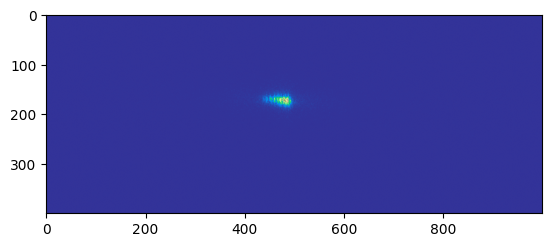

In [11]:
import matplotlib.pyplot as plt

def get_frames_for_scan(scan_number):
    frames = view.frames.filter(view.frames["scan_number"].eq(scan_number))
    return frames

# Get the frames for the i0 scan
i0_frames = get_frames_for_scan(88174)
test_img = get_image(i0_frames, 1)
plt.imshow(test_img, cmap="terrain")
plt.show()

In [99]:
import numpy as np
from dataclasses import dataclass

@dataclass
class BeamLocation:
    row: int
    col: int

def bg_subtract(image):
    quartiles = np.percentile(image, [5])
    # Subtract the 5th percentile from the image
    image = image - quartiles[0]
    return image

def edge_subtract(image):
    # Use the edge of the image as a metric for the background using 5 pixels from the edge
    left = image[:, :5]
    right = image[:, -5:]
    top = image[:5, :]
    bottom = image[-5:, :]
    edge_mean = (left.mean() + right.mean() + top.mean() + bottom.mean()) / 4
    image = image - edge_mean
    return image

def pre_process(image):
    # Slice the left, right, top, bottom 10% of the image
    image = image[10:-10, 10:-10]
    # Perform a background subtraction
    image = bg_subtract(image)
    image = edge_subtract(image)
    return image

def direct_beam(image):
    # Get the
    processed_image = pre_process(image)
    # Find the location of the max value in the image
    max_row, max_col = np.unravel_index(processed_image.argmax(), processed_image.shape)
    raw_max = BeamLocation(row=max_row, col=max_col)
    # Per row integration and look for a peak in the integrated signal
    integrated_signal = np.sum(processed_image, axis=1)
    peak_row = int(np.argmax(integrated_signal))
    # Get the col from the max in the peak row
    peak_col = int(np.argmax(processed_image[peak_row, :]))
    peak_location = BeamLocation(row=peak_row, col=peak_col)
    return raw_max, mid_point, peak_location

# Dataframe constructor on the beamspot locations to compare each method

data = []

# Build a mapping from frame_number to its position/index in the dataframe, if required by get_image
if "frame_number" in i0_frames.columns:
    # Get index positions of each frame number
    frame_to_idx = {frame: idx for idx, frame in enumerate(i0_frames["frame_number"])}
else:
    frame_to_idx = {}

for frame in i0_frames["frame_number"].unique():
    # Defensive: handle potential missing frames or mismatch in index
    idx = frame_to_idx.get(frame, None)
    try:
        image = get_image(i0_frames, idx if idx is not None else frame)
        result = direct_beam(image)
        # Handle older direct_beam return signature
        if len(result) == 3:
            raw_max, mid_point, peak_location = result
        else:
            raw_max, peak_location = result
        energy_series = i0_frames.filter(pl.col("frame_number").eq(frame))["Beamline Energy"].unique()
        energy = energy_series[0] if len(energy_series) else None
        data.append({
            "method": "direct_beam",
            "frame_number": frame,
            "row": raw_max.row,
            "col": raw_max.col,
            "energy": energy,
        })
        data.append({
            "method": "peak_location",
            "frame_number": frame,
            "row": peak_location.row,
            "col": peak_location.col,
            "energy": energy,
        })
    except Exception as e:
        print(f"Skipping frame {frame} due to error: {e}")

dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered
dataframe fi

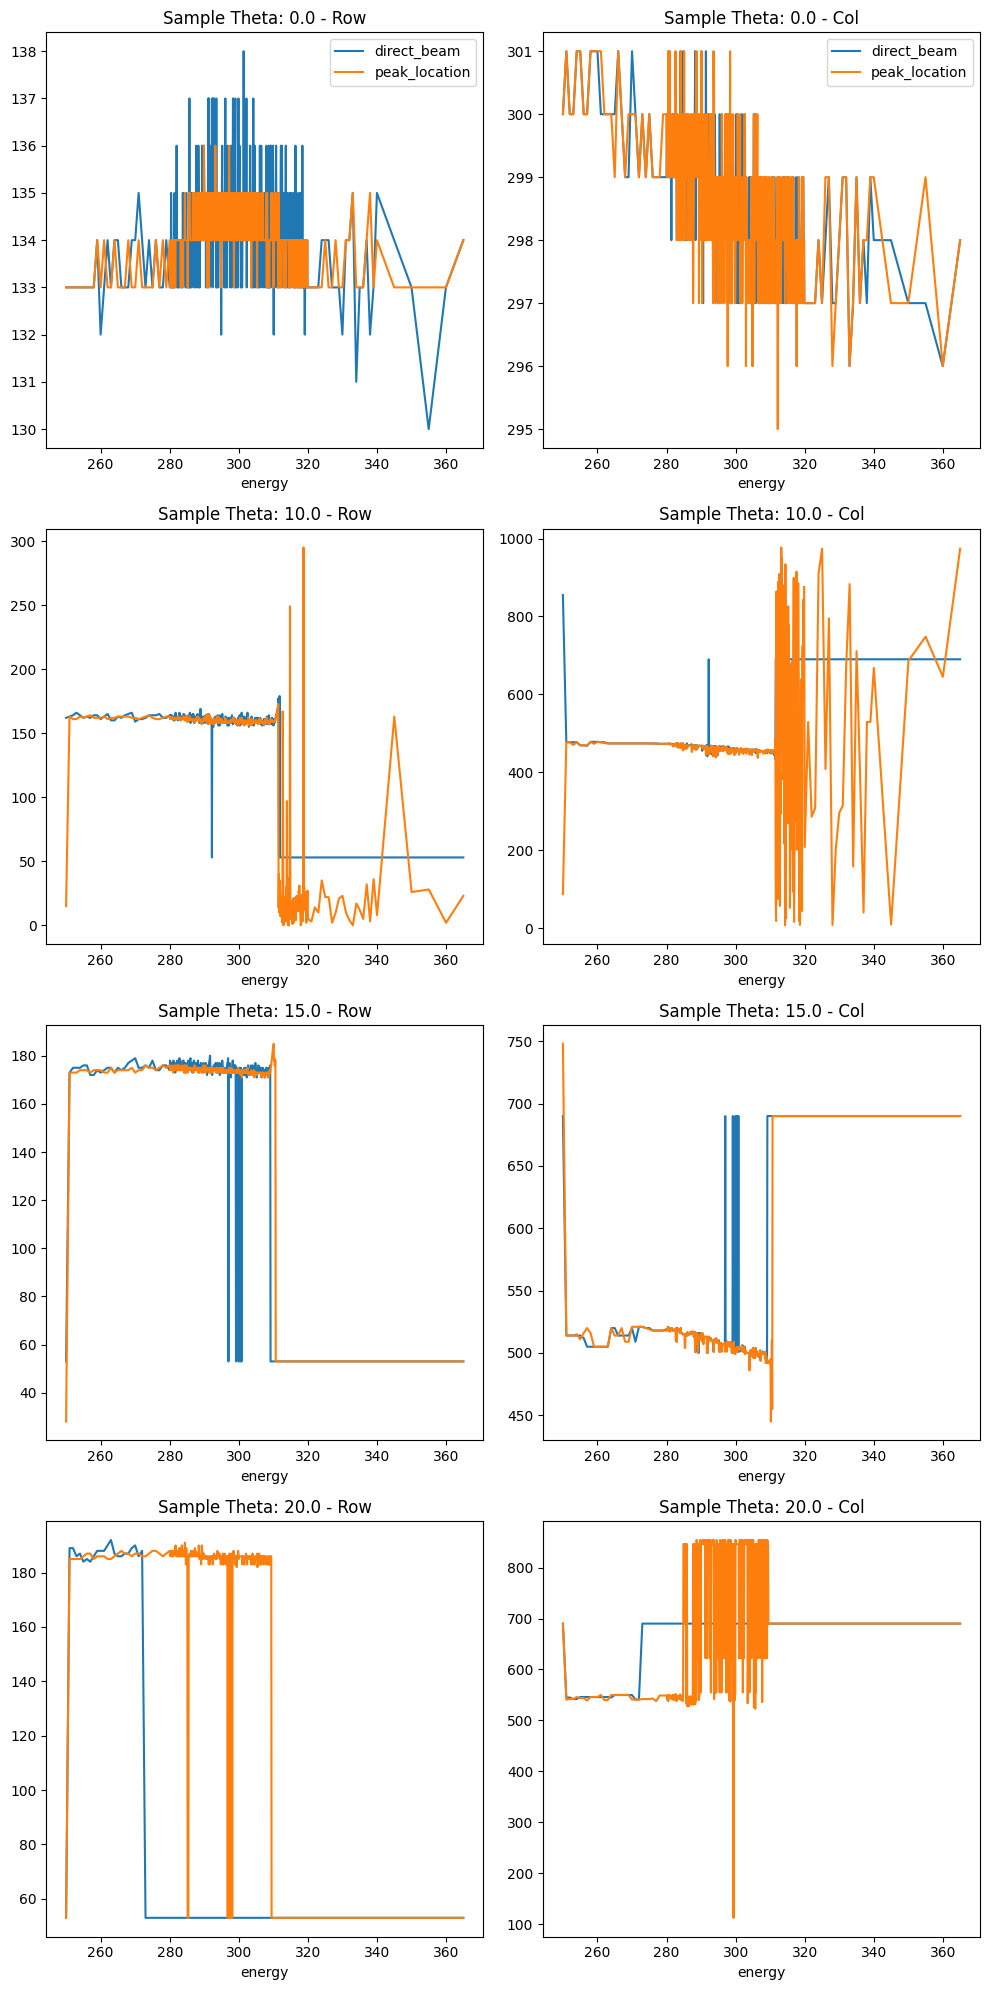

In [100]:
import pandas as pd

df = pd.DataFrame(data)

# Determine unique sample thetas; assume 'Sample Theta' exists in i0_frames and corresponds to frame_number
if "Sample Theta" in i0_frames.columns:
    frame_to_theta = dict(zip(i0_frames["frame_number"], i0_frames["Sample Theta"]))
    df["Sample Theta"] = df["frame_number"].map(frame_to_theta)
else:
    raise ValueError("i0_frames does not contain 'Sample Theta' column.")

sample_thetas = sorted(df["Sample Theta"].dropna().unique())
n_theta = len(sample_thetas)

fig, axs = plt.subplots(n_theta, 2, figsize=(10, 5 * n_theta), squeeze=False)
colors = {"direct_beam": "tab:blue", "peak_location": "tab:orange"}

for row_idx, theta in enumerate(sample_thetas):
    theta_df = df[df["Sample Theta"] == theta]
    for col_idx, (method, group) in enumerate(theta_df.groupby("method")):
        ax_row = axs[row_idx]
        # The two columns: one for "row", one for "col"
        group.sort_values("energy").plot(
            x="energy",
            y="row",
            ax=ax_row[0] if len(ax_row) > 1 else ax_row,
            ls="-",
            color=colors.get(method, None),
            legend=(row_idx == 0),
            label=method
        )
        group.sort_values("energy").plot(
            x="energy",
            y="col",
            ax=ax_row[1] if len(ax_row) > 1 else ax_row,
            ls="-",
            color=colors.get(method, None),
            legend=(row_idx == 0),
            label=method
        )
    # Set titles
    axs[row_idx][0].set_title(f"Sample Theta: {theta} - Row")
    axs[row_idx][1].set_title(f"Sample Theta: {theta} - Col")

plt.tight_layout()
plt.show()

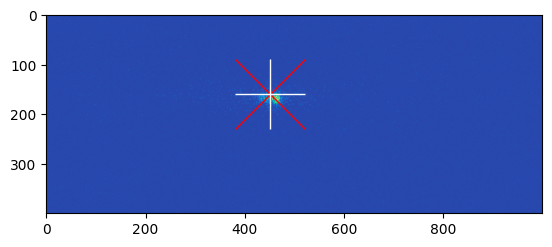

In [101]:
def preview_image(frame_number):
    img = get_image(i0_frames, frame_number)
    plt.imshow(img, cmap="terrain")
    loc = df[df["method"] == "direct_beam"].iloc[frame_number]
    loc2 = df[df["method"] == "peak_location"].iloc[frame_number]
    plt.plot([loc["col"]], [loc["row"]], "x", color="red", ms=50)
    plt.plot([loc2["col"]], [loc2["row"]], "+", color="white", ms=50)
    plt.show()

preview_image(300)


In [104]:
# Integrate the signal in a 10x10 pixel box centered on the peak location

def integrate_signal(image, peak_location):
    processed_image = pre_process(image)
    # Get the 10x10 pixel box centered on the peak location
    box_size = 10
    start_row = peak_location.row - box_size // 2
    start_col = peak_location.col - box_size // 2
    end_row = start_row + box_size
    end_col = start_col + box_size
    # Integrate the signal in the box
    signal = np.sum(processed_image[start_row:end_row, start_col:end_col])
    return signal

# Integrate the signal in a 10x10 pixel box centered on the peak location
data = []
for frame_number in range(len(i0_frames)):
    image = get_image(i0_frames, frame_number)
    peak_location = df[df["method"] == "peak_location"].iloc[frame_number]
    signal = integrate_signal(image, peak_location)
    data.append({
        "frame_number": frame_number,
        "energy": i0_frames[frame_number]["Beamline Energy"][0],
        "sam_theta": i0_frames[frame_number]["Sample Theta"][0],
        "signal": signal,
    })
refl_df = pd.DataFrame(data)

In [105]:
refl_df["sam_theta"].unique()

array([10., 15., 20.,  0.])

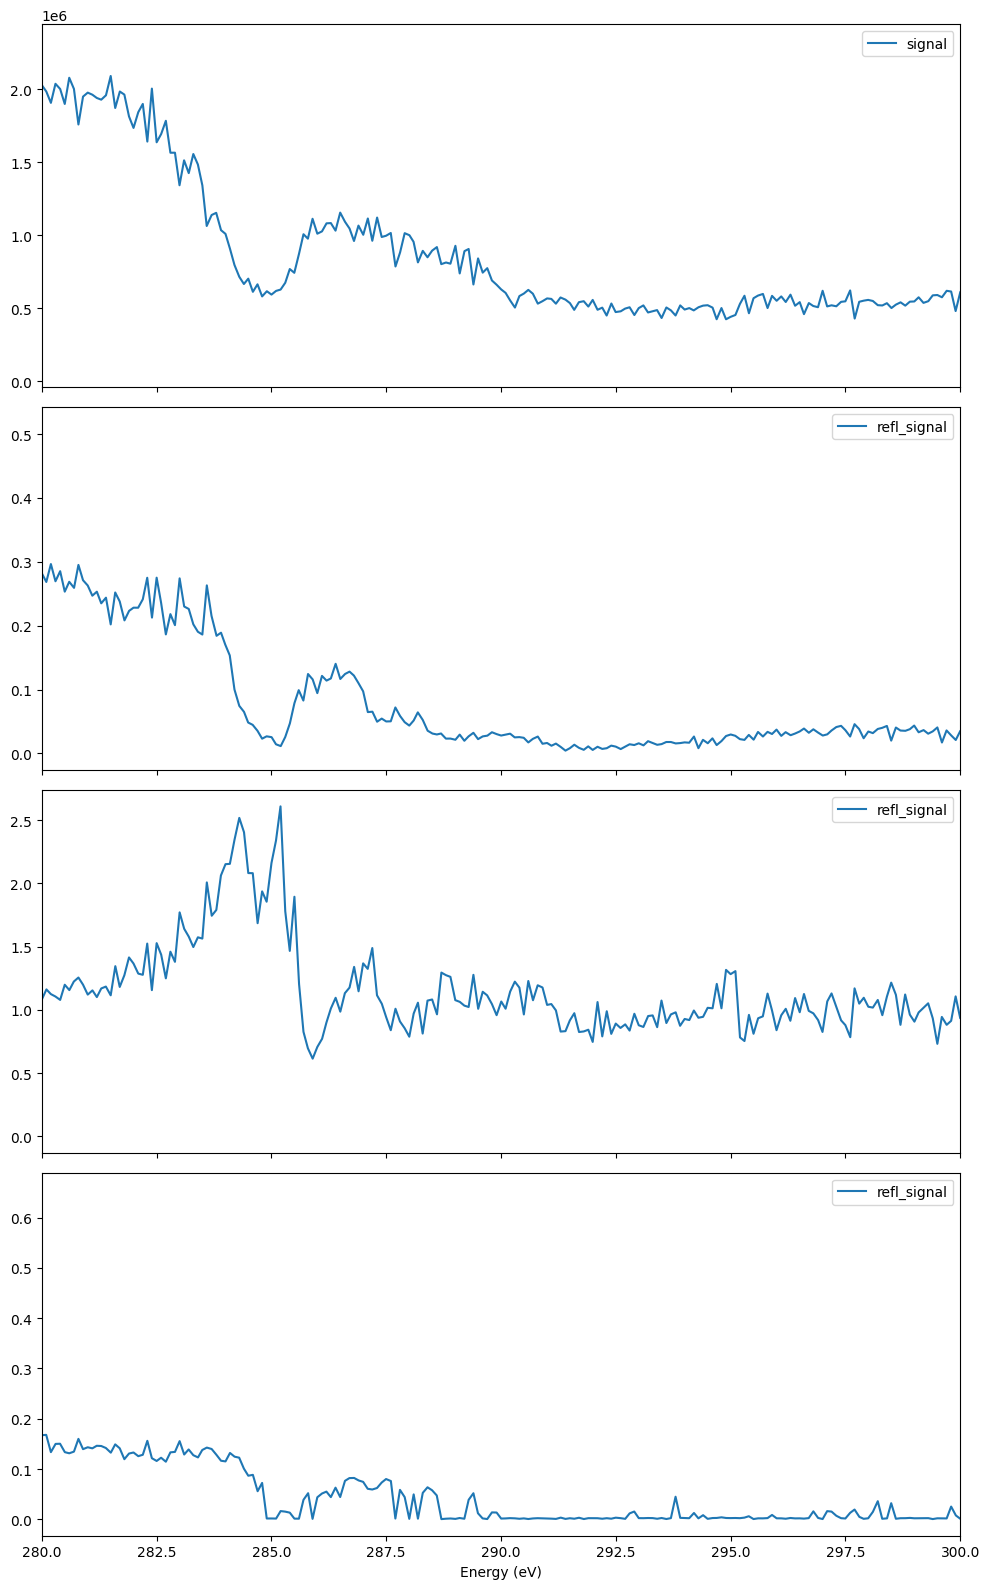

In [109]:
# Use the sam_theta = 0 for the izero and plot the signal / i0 vs energy
fig, ax = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(10, 4*4),
    sharex=True,
    sharey=False,
)

i0_df = refl_df[refl_df["sam_theta"] == 0].copy()
i0_df.plot(x="energy", y="signal", kind="line", ax=ax[0])

df_10 = refl_df[refl_df["sam_theta"] == 10.0].copy()
df_10.loc[:, "refl_signal"] = df_10["signal"].values / i0_df["signal"].values
df_10.plot(x="energy", y="refl_signal", kind="line", ax=ax[1])

df_15 = refl_df[refl_df["sam_theta"] == 15.0].copy()
df_15.loc[:, "refl_signal"] = df_15["signal"].values / i0_df["signal"].values
df_15.plot(x="energy", y="refl_signal", kind="line", ax=ax[2])

df_20 = refl_df[refl_df["sam_theta"] == 20.0].copy()
df_20.loc[:, "refl_signal"] = df_20["signal"].values / i0_df["signal"].values
df_20.plot(x="energy", y="refl_signal", kind="line", ax=ax[3])

ax[-1].set_xlabel("Energy (eV)")
ax[-1].set_xlim(280, 300)
plt.tight_layout()
plt.show()
